change the data into ethical /unhetical professions

add one hot encoding for all columns 
remove badges

In [36]:
import pandas as pd 
import numpy as np 

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import shap
from scipy.stats import  pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
import scipy

In [2]:
data = pd.read_csv("pokemon_data.csv")

# preprocessing

In [3]:
data.columns

Index(['Unnamed: 0', 'Age', 'Economic Status', 'Profession',
       'Average Pokemon Level', 'Criminal Record', 'Win Ratio',
       'Battle Strategy', 'Number of Migrations', 'Debt to Kanto',
       'Charity Participation', 'Team Rocket'],
      dtype='object')

In [4]:
data.drop('Unnamed: 0', axis=1, inplace=True)


In [5]:
data.columns

Index(['Age', 'Economic Status', 'Profession', 'Average Pokemon Level',
       'Criminal Record', 'Win Ratio', 'Battle Strategy',
       'Number of Migrations', 'Debt to Kanto', 'Charity Participation',
       'Team Rocket'],
      dtype='object')

In [6]:
data["Debt"] = data["Debt to Kanto"] > 100000
data["Debt"] = data["Debt"].map({True:1, False:0})

In [7]:
data = data.drop("Debt to Kanto", axis=1)

In [8]:
cols = ['Economic Status', "Profession", "Battle Strategy"]

df_processed = pd.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=True)

In [9]:
y = df_processed["Team Rocket"]
X = df_processed.drop("Team Rocket", axis=1)

In [10]:
X

,Age,Average Pokemon Level,Criminal Record,Win Ratio,Number of Migrations,Charity Participation,Debt,Economic Status_Low,Economic Status_Middle,Profession_Black Market Dealer,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
0,27,50,0,51,25,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,55,35,1,53,19,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,14,96,0,76,18,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,41,23,0,27,10,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
4,15,16,1,51,17,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4050,48,55,1,33,24,0,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
4051,31,6,1,78,8,1,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1
4052,10,63,1,54,19,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4053,63,26,1,43,12,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## scaling the data


In [12]:
# Choose only the columns you want to scale
cols_to_scale = ["Age", "Win Ratio", "Average Pokemon Level", "Number of Migrations"]

# Fit scaler only on these columns
scaler = StandardScaler().fit(X_train[cols_to_scale])

# Transform only these columns
X_train_scaled_part = scaler.transform(X_train[cols_to_scale])
X_test_scaled_part = scaler.transform(X_test[cols_to_scale])

# Keep the other columns untouched
X_train_other = X_train.drop(columns=cols_to_scale)
X_test_other = X_test.drop(columns=cols_to_scale)



# Create DataFrames
X_train_scaled = pd.DataFrame(
    np.hstack([X_train_scaled_part, X_train_other.values]),
    columns=cols_to_scale + list(X_train_other.columns),
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    np.hstack([X_test_scaled_part, X_test_other.values]),
    columns=cols_to_scale + list(X_test_other.columns),
    index=X_test.index
)


# correlation analysis 

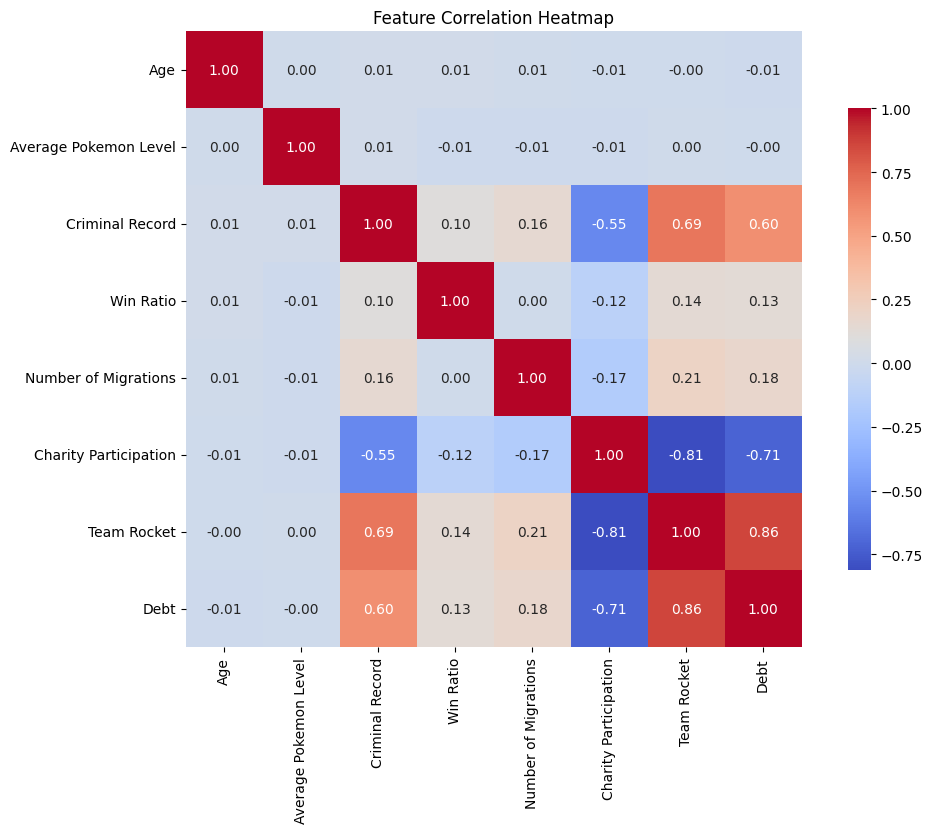

In [13]:


# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .75})

# Set title
plt.title("Feature Correlation Heatmap")

# Show plot
plt.show()

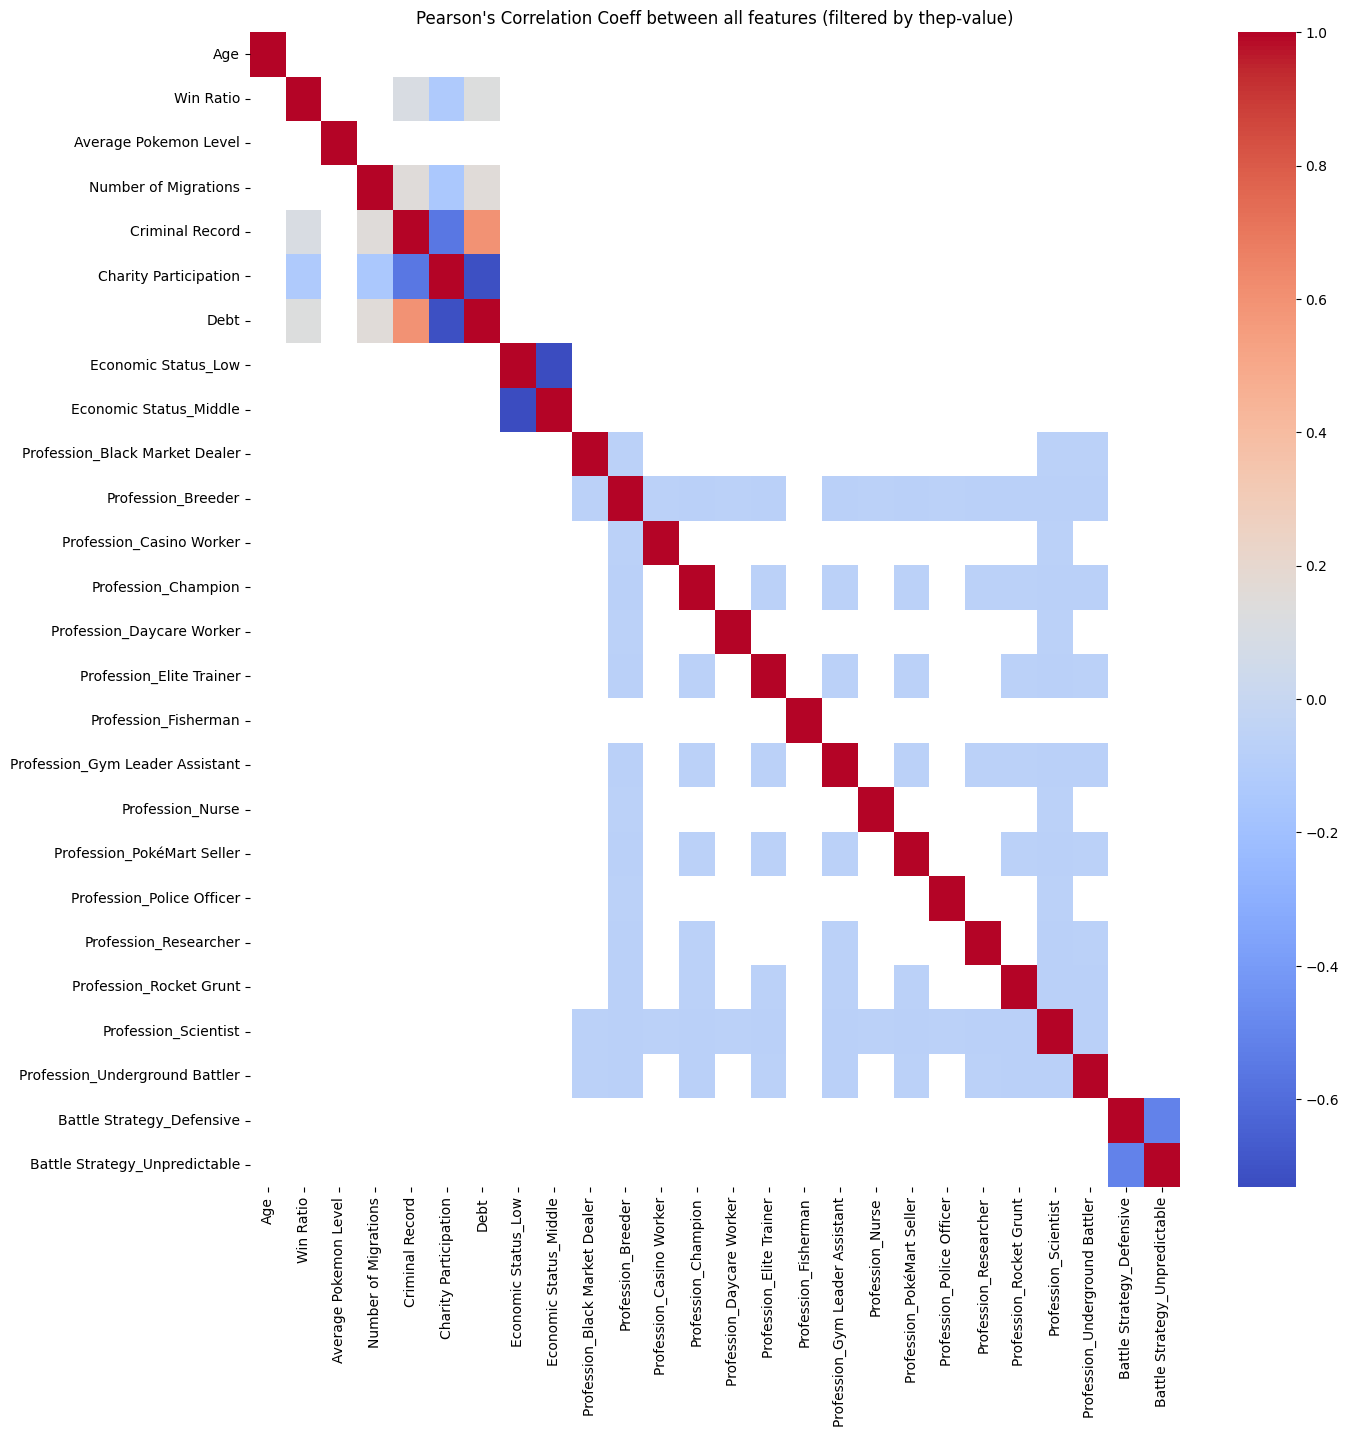

In [14]:
n_features = X_train_scaled.shape[1]

alpha = 0.05
corrected_alpha = alpha/ (n_features**2/2)

corr = np.zeros((n_features, n_features))
p = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr[i,j], p[i,j] = pearsonr(X_train_scaled.iloc[:,i], X_train_scaled.iloc[:,j])
        if np.isnan(corr[i,j]):
            p[i,j] = 1


### Visualise full correlarion matrix
plt.figure(figsize=(15,15))
sns.heatmap(corr, cmap="coolwarm", xticklabels=X_train_scaled.columns, yticklabels=X_train_scaled.columns, mask= p > corrected_alpha) ## mask if p is higher
plt.title("Pearson's Correlation Coeff between all features (filtered by thep-value)")
plt.show()

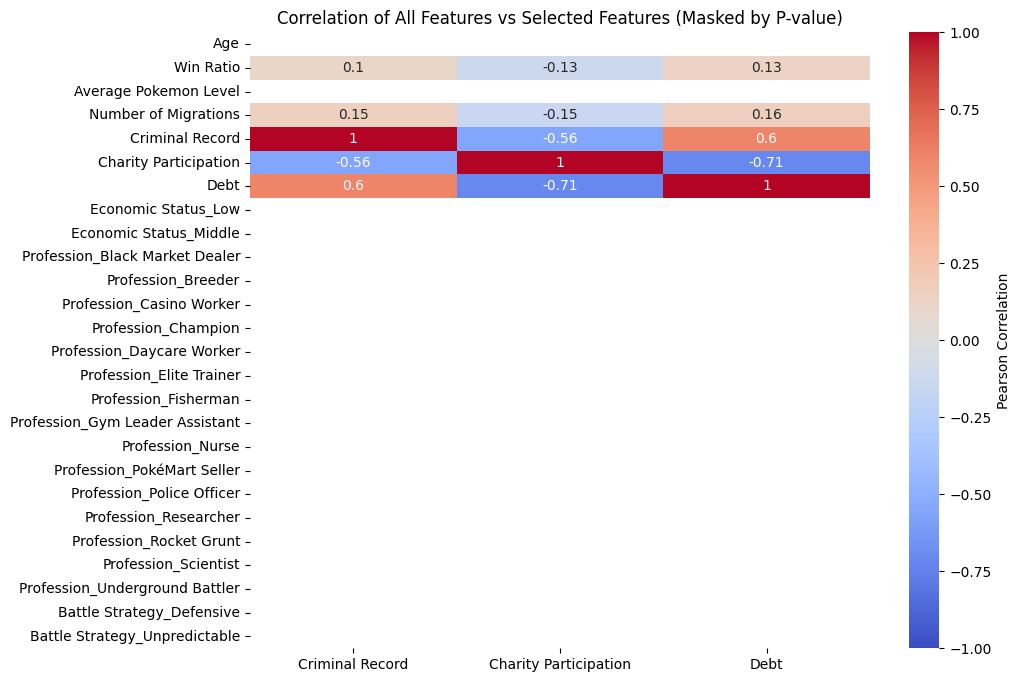

In [15]:
# Now select only columns 2, 4, 5 (and the corresponding rows)
selected_indices = [4, 5, 6]

corr_selected = corr[:, selected_indices]
p_selected = p[:, selected_indices]

# Build the mask: True where p > corrected_alpha
mask = p_selected > corrected_alpha

# Get full row names and selected column names
row_names = X_train_scaled.columns
col_names = X_train_scaled.columns[selected_indices]

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_selected, 
    mask=mask,                  # Apply mask here
    xticklabels=col_names, 
    yticklabels=row_names,
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, vmax=1,
    cbar_kws={"label": "Pearson Correlation"}
)
plt.title("Correlation of All Features vs Selected Features (Masked by P-value)")
plt.show()

# training

## random forest

In [16]:
forest = RandomForestClassifier(max_depth = 5, random_state=23, n_jobs=-1, n_estimators=20)
forest.fit(X_train_scaled, y_train)
forest_y_pred = forest.predict(X_test_scaled)
forest_accuracy = accuracy_score(y_test, forest_y_pred)
forest_accuracy

0.9975339087546239

## logistic regression

### logistic basic 

In [17]:
X_test_scaled

,Age,Win Ratio,Average Pokemon Level,Number of Migrations,Criminal Record,Charity Participation,Debt,Economic Status_Low,Economic Status_Middle,Profession_Black Market Dealer,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
3567,-0.076606,-0.444550,-1.026843,1.107935,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
140,-0.361986,0.872070,0.029451,-1.200029,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1313,1.578601,-0.602545,0.029451,-0.943588,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
432,0.608307,0.292757,0.357267,-1.328249,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3506,-1.731813,-0.286556,-0.334788,-1.200029,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226,-0.647367,1.030065,-1.136114,1.492595,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
671,1.293221,0.503417,1.012897,1.877256,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1054,-0.304910,0.661411,-0.589755,-0.430708,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3671,0.151699,0.134763,0.029451,-1.200029,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:

logistic_model = LogisticRegression(max_iter=5000, penalty=None, C=0.8497534359086438, tol=1e-4, solver="saga")

# Fit the model
logistic_model.fit(X_train_scaled, y_train)

# Predictions
log_y_pred = logistic_model.predict(X_test_scaled)
log_y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

Setting penalty=None will ignore the C and l1_ratio parameters


In [19]:

log_accuracy = accuracy_score(y_test, log_y_pred)
log_accuracy

0.9950678175092479

### logistic without protected attributes

In [20]:
X_train_np = X_train_scaled.drop(columns= [ "Criminal Record", "Charity Participation", "Debt"], axis=1)
X_test_np = X_test_scaled.drop(columns= ["Criminal Record", "Charity Participation", "Debt"], axis=1)

In [21]:
group_test_dict = {
    "Criminals": X_test_scaled["Criminal Record"] == 1.0, 
    "Non_Criminals": X_test_scaled["Criminal Record"] == 0.0,
    "Charity_givers": X_test_scaled["Charity Participation"] ==1.0,
    "Non_Charity_givers": X_test_scaled["Charity Participation"] ==1.0,
    "Big_Debt": X_test_scaled["Debt"] == 1.0,
    "Small_Debt": X_test_scaled["Debt"] == 0.0
}

In [29]:
X_train_np

,Age,Win Ratio,Average Pokemon Level,Number of Migrations,Economic Status_Low,Economic Status_Middle,Profession_Black Market Dealer,Profession_Breeder,Profession_Casino Worker,Profession_Champion,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
4026,1.578601,-1.129193,0.685082,0.338614,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2169,-1.446432,-0.339221,-1.172538,0.723274,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3085,0.208775,-1.181858,-0.844723,-0.687148,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2523,-0.361986,1.135395,-1.136114,-0.046047,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2054,0.608307,-0.339221,0.284419,-1.200029,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,1.064916,-0.865869,-1.682473,0.466834,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1366,-0.761519,-0.918534,-0.116244,1.620815,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
778,-0.704443,1.082730,0.466538,-0.174267,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2750,-0.133682,0.556081,0.357267,1.107935,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [32]:
logistic_model2 = LogisticRegression(max_iter=5000, penalty=None, C=0.8497534359086438, tol=1e-4, solver="saga")

logistic_model2.fit(X_train_np, y_train)
y_hat= logistic_model2.predict(X_test_np)
log_accuracy_np = accuracy_score(y_test, y_hat)
log_accuracy_np

Setting penalty=None will ignore the C and l1_ratio parameters


0.7891491985203453

In [31]:
logistic_model2.coef_

array([[ 0.03007223,  0.3842258 ,  0.01126061,  0.51471426,  0.04358193,
         0.01790936,  0.49320382,  0.10162152,  0.11768253, -0.30721247,
         0.15329431,  0.03492427,  0.01006458,  0.14585277,  0.20635225,
         0.2302735 ,  0.14180691,  0.12963606,  0.36369745,  0.17758301,
         0.21515403, -0.28579015, -0.19376988]])

In [23]:
# Calculate and print F1 Scores for each group
for group, group_idxs in group_test_dict.items():
    print(f'F1, {group}: {f1_score(y_test[group_idxs], y_hat[group_idxs]):.2f}')

# Calculate and print positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Positive Rate, {group}: {np.mean(y_hat[group_idxs]):.2f}')
    # Calculate and print positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Accuracy, {group}: {accuracy_score(y_test[group_idxs],y_hat[group_idxs]):.2f}')

F1, Criminals: 0.00
F1, Non_Criminals: 0.02
F1, Charity_givers: 0.00
F1, Non_Charity_givers: 0.00
F1, Big_Debt: 0.01
F1, Small_Debt: 0.00
Positive Rate, Criminals: 0.00
Positive Rate, Non_Criminals: 0.00
Positive Rate, Charity_givers: 0.00
Positive Rate, Non_Charity_givers: 0.00
Positive Rate, Big_Debt: 0.01
Positive Rate, Small_Debt: 0.00
Accuracy, Criminals: 0.00
Accuracy, Non_Criminals: 0.88
Accuracy, Charity_givers: 0.93
Accuracy, Non_Charity_givers: 0.93
Accuracy, Big_Debt: 0.01
Accuracy, Small_Debt: 0.94


# Fair PCA

In [33]:
X_train_scaled

,Age,Win Ratio,Average Pokemon Level,Number of Migrations,Criminal Record,Charity Participation,Debt,Economic Status_Low,Economic Status_Middle,Profession_Black Market Dealer,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
4026,1.578601,-1.129193,0.685082,0.338614,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2169,-1.446432,-0.339221,-1.172538,0.723274,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3085,0.208775,-1.181858,-0.844723,-0.687148,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2523,-0.361986,1.135395,-1.136114,-0.046047,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2054,0.608307,-0.339221,0.284419,-1.200029,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,1.064916,-0.865869,-1.682473,0.466834,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1366,-0.761519,-0.918534,-0.116244,1.620815,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
778,-0.704443,1.082730,0.466538,-0.174267,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2750,-0.133682,0.556081,0.357267,1.107935,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [37]:
class FairPCA:
    def __init__(self, Xs, p_idxs, n_components):
        Xs = Xs.values
        self.fit(Xs, p_idxs, n_components)

    def fit(self, Xs, p_idxs, n_components):
        # Extract protected features
        Xs_p = Xs[:, p_idxs]

        # Compute projection matrix (U)
        Z = Xs_p
        #Z = Z - Z.mean(0) # Since we alredy standardised everything, there is not much sense in removing the mean
        R = scipy.linalg.null_space(Z.T @ Xs)
        eig_vals, L = scipy.linalg.eig(R.T @ Xs.T @ Xs @ R)
        self.U = R @ L[:, :n_components]

    def project(self, Xs):
        return Xs @ self.U
    
fair_pca = FairPCA(X_train_scaled, [4, 5, 6], 30)
Xs_train_debiased = fair_pca.project(X_train_scaled)
Xs_test_debiased = fair_pca.project(X_test_scaled)

In [41]:
X_train_p = X_train_scaled[["Criminal Record", "Charity Participation", "Debt"]]
X_test_p = X_test_scaled[["Criminal Record", "Charity Participation", "Debt"]]

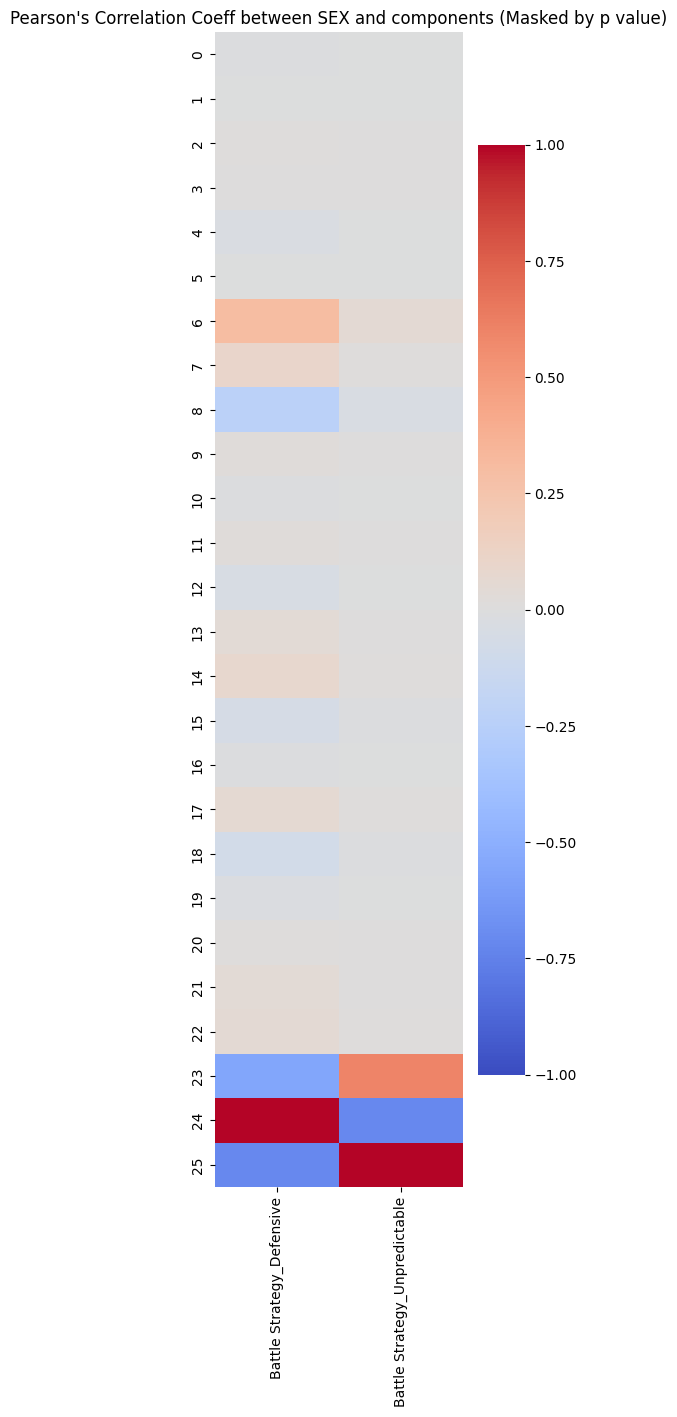

In [43]:
# Compute correlation matrix
Xs_train_debiased_p = np.concatenate([Xs_train_debiased, X_train_p], axis=1)
n_features = Xs_train_debiased_p.shape[1]
corr_ = np.zeros((n_features, n_features))
p_ = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr_[i,j], p_[i,j] = pearsonr(Xs_train_debiased_p[:,i], Xs_train_debiased_p[:,j])
        corr_ = np.nan_to_num(corr_, 0)

# Plot correlations with protected features
plt.figure(figsize=(4,15))
sns.heatmap(corr_[:,-2:], cmap="coolwarm", xticklabels=X_train_scaled.columns[-2:], vmin=-1, vmax=1)
plt.title("Pearson's Correlation Coeff between SEX and components (Masked by p value)")
plt.show()

## SHAP

using the shap library to see which are the features that influence decisions the most


In [25]:
features = X_train_scaled.columns

In [26]:
explainer = shap.Explainer(logistic_model, X_train_scaled, feature_names=features)
shap_values_log = explainer(X_test_scaled)

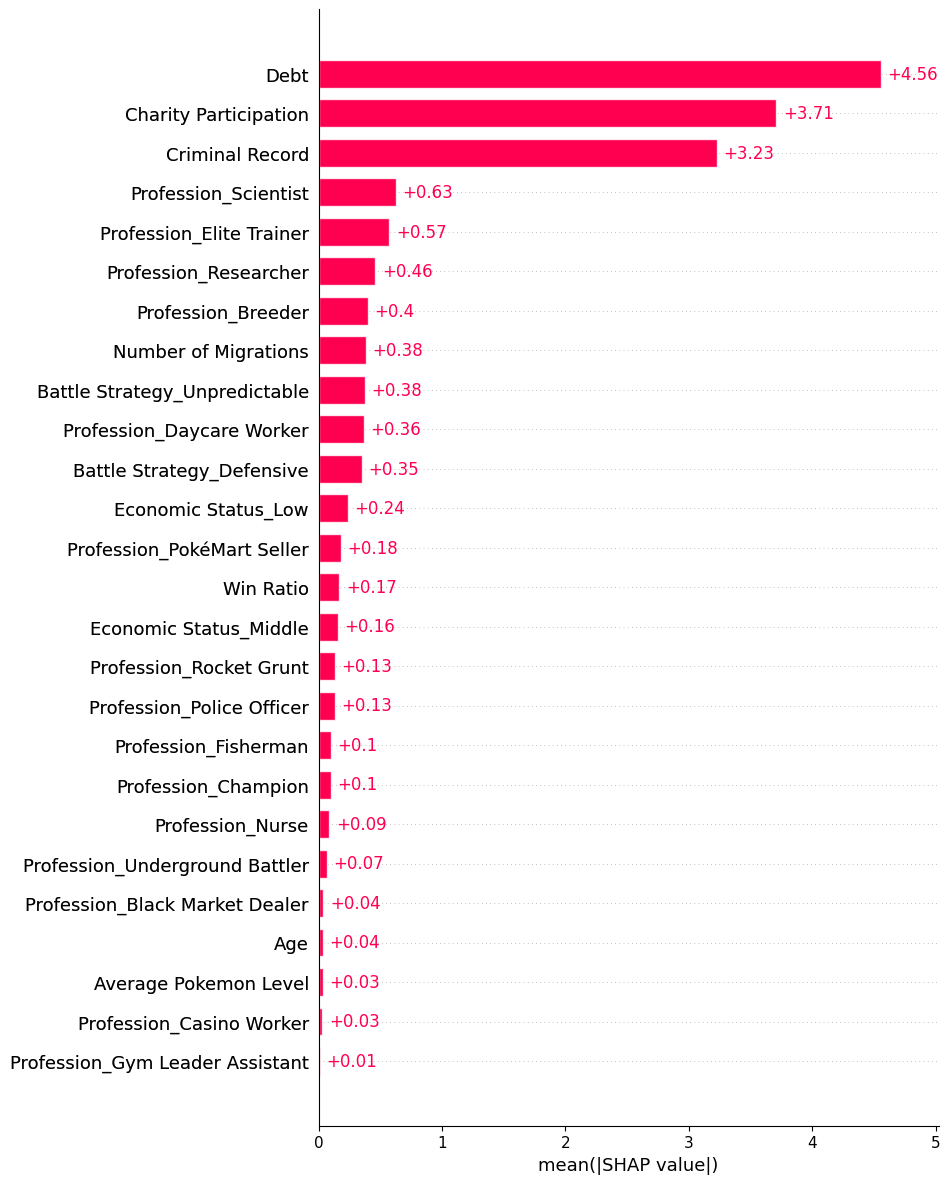

In [27]:
shap.plots.bar(shap_values_log, max_display=33)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


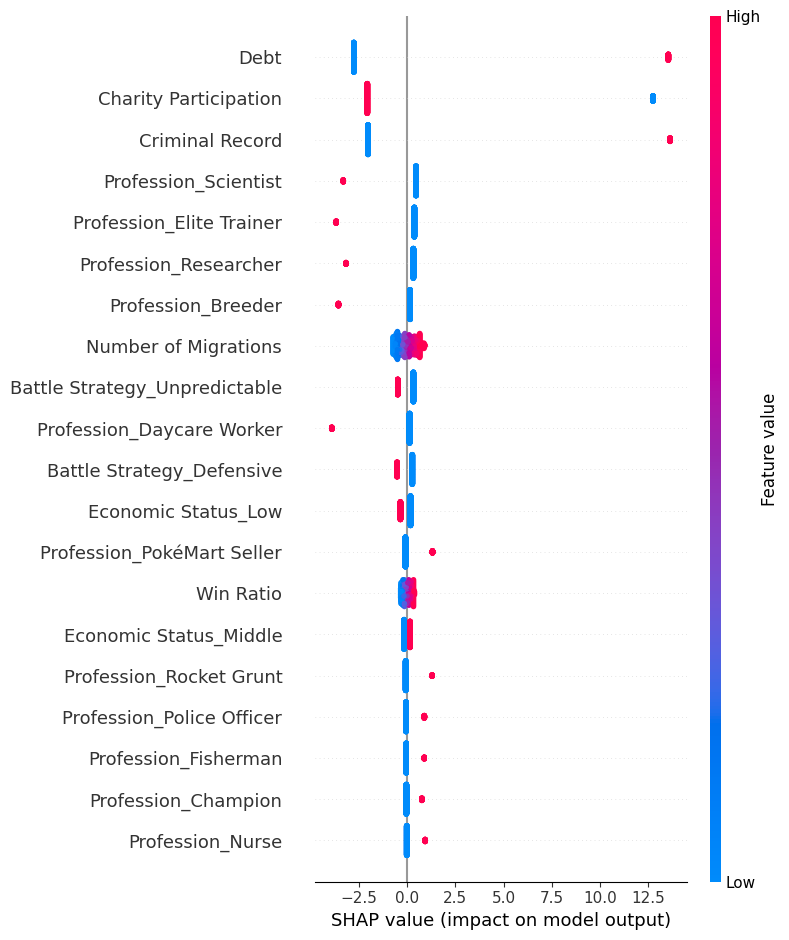

In [28]:
shap.summary_plot(shap_values_log, X_test_scaled)